Multi-class classification

In [1]:
import torch
torch.cuda.is_available()

True

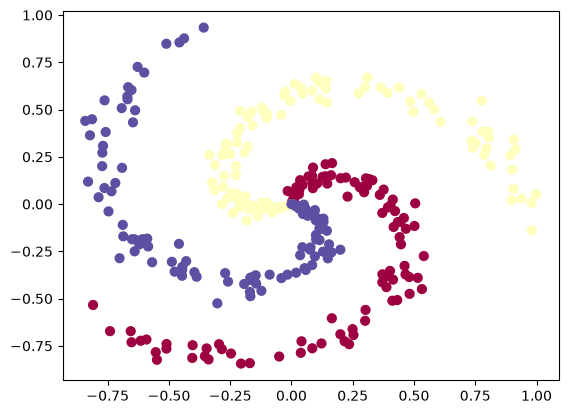

In [2]:
import matplotlib.pyplot as plt
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [3]:
X[:5],y[:5], X.shape, y.shape

(array([[-0.        ,  0.        ],
        [ 0.00160659,  0.00997243],
        [ 0.00548826,  0.01944224],
        [ 0.01111591,  0.02819061],
        [ 0.01048006,  0.03902121]]),
 array([0, 0, 0, 0, 0], dtype=uint8),
 (300, 2),
 (300,))

In [4]:
X= torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

In [5]:
X[:5],y[:5], X.shape, y.shape

(tensor([[-0.0000, 0.0000],
         [0.0016, 0.0100],
         [0.0055, 0.0194],
         [0.0111, 0.0282],
         [0.0105, 0.0390]]),
 tensor([0., 0., 0., 0., 0.]),
 torch.Size([300, 2]),
 torch.Size([300]))

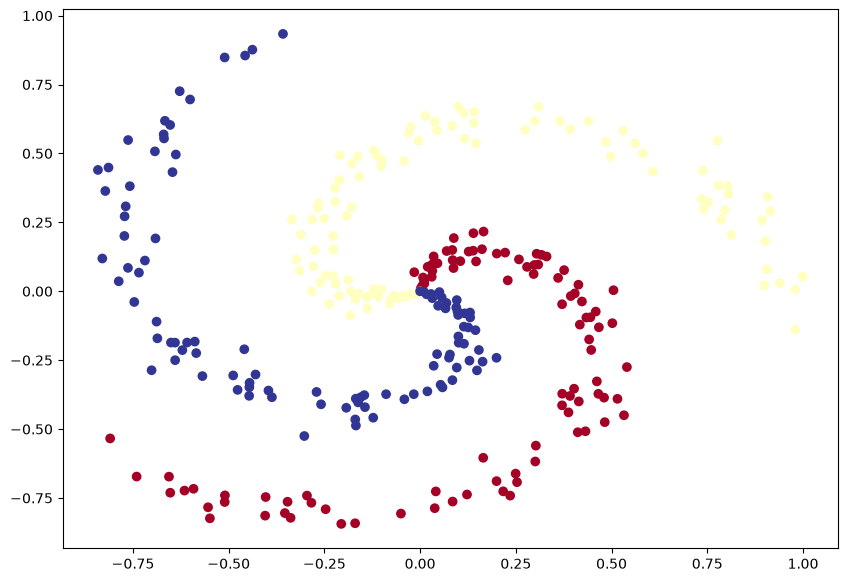

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                            X,y, train_size=0.8,random_state=42
)

In [8]:
X_train[:5],X_test[:5],y_train[:5], y_test[:5]

(tensor([[ 0.1485, -0.2871],
         [ 0.4655, -0.3722],
         [ 0.0303,  0.0525],
         [ 0.7388,  0.4375],
         [ 0.3097,  0.6692]]),
 tensor([[ 0.0287, -0.0099],
         [-0.6401, -0.1864],
         [-0.1207,  0.5112],
         [ 0.0199,  0.0887],
         [ 0.0843, -0.3225]]),
 tensor([2., 0., 0., 1., 1.]),
 tensor([2., 2., 1., 0., 2.]))

In [9]:
#Build the model
from torch import nn

class multiclass_model(nn.Module):
    def __init__(self,in_features=2,hidden_features1=16,hidden_features2=8,out_features=4):
        super().__init__()
        self.layer1=nn.Linear(in_features=in_features,out_features=hidden_features1)
        self.layer2=nn.Linear(in_features=hidden_features1,out_features=hidden_features2)
        self.layer3=nn.Linear(in_features=hidden_features2,out_features=out_features)
        self.relu=nn.ReLU()
        #self.sigmoid=nn.Sigmoid()
    def forward(self,X):
        #return self.sigmoid(self.layer3(self.relu(self.layer2(self.relu(self.layer1(X))))))
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(X)))))

In [10]:
model12=multiclass_model()
model12

multiclass_model(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=4, bias=True)
  (relu): ReLU()
)

In [11]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(params=model12.parameters(), lr=0.01)

In [12]:
y_train=y_train.long()
y_test=y_test.long()

In [13]:
device="cuda" if torch.cuda.is_available() else "cpu"

model12=model12.to(device)
X_train=X_train.to(device)
X_test=X_test.to(device)
y_train=y_train.to(device)
y_test=y_test.to(device)

In [14]:
print("Model12:", next(model12.parameters()).device)
print("X_train:", X_train.device)
print("X_test:", X_test.device)
print("y_train:", y_train.device)
print("y_test:", y_test.device)

Model12: cuda:0
X_train: cuda:0
X_test: cuda:0
y_train: cuda:0
y_test: cuda:0


In [15]:
X_train.dtype,X_test.dtype,y_train.dtype,y_test.dtype

(torch.float32, torch.float32, torch.int64, torch.int64)

In [16]:
print(X_train.shape)
print(y_train.shape)
print(model12(X_train).shape)

torch.Size([240, 2])
torch.Size([240])
torch.Size([240, 4])


In [17]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [18]:
import torchmetrics

# initialize metric
metric = torchmetrics.classification.Accuracy(task="multiclass", num_classes=4).to(device)

In [19]:
epochs=1000
for epoch in range(epochs):
    epoch+=1
    model12.train()
    y_preds=model12(X_train)
    loss=loss_fn(y_preds,y_train)
    acc = metric(y_preds, y_train) 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model12.eval()
    with torch.inference_mode():
        y_preds_now=model12(X_test)
        test_loss=loss_fn(y_preds_now,y_test)
        test_acc = metric(y_preds_now, y_test)
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc*100:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc*100:.2f}%")

Epoch: 100 | Loss: 0.18337, Acc: 94.17% | Test Loss: 0.18477, Test Acc: 91.67%
Epoch: 200 | Loss: 0.05743, Acc: 99.17% | Test Loss: 0.04512, Test Acc: 98.33%
Epoch: 300 | Loss: 0.03785, Acc: 99.17% | Test Loss: 0.01661, Test Acc: 100.00%
Epoch: 400 | Loss: 0.02986, Acc: 99.17% | Test Loss: 0.00736, Test Acc: 100.00%
Epoch: 500 | Loss: 0.02539, Acc: 99.17% | Test Loss: 0.00372, Test Acc: 100.00%
Epoch: 600 | Loss: 0.02249, Acc: 99.17% | Test Loss: 0.00209, Test Acc: 100.00%
Epoch: 700 | Loss: 0.02039, Acc: 99.17% | Test Loss: 0.00129, Test Acc: 100.00%
Epoch: 800 | Loss: 0.01901, Acc: 99.17% | Test Loss: 0.00091, Test Acc: 100.00%
Epoch: 900 | Loss: 0.01805, Acc: 99.17% | Test Loss: 0.00067, Test Acc: 100.00%
Epoch: 1000 | Loss: 0.01732, Acc: 99.17% | Test Loss: 0.00055, Test Acc: 100.00%


In [20]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


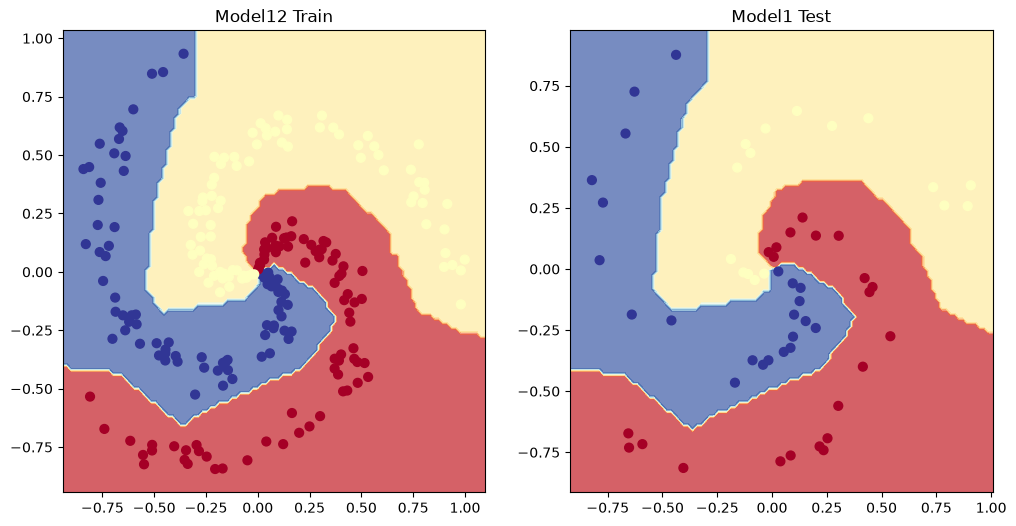

In [21]:
# Plot decision boundaries for training and test sets
import matplotlib.pyplot as plt
from helper_functions import plot_decision_boundary, plot_predictions

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Model12 Train")
plot_decision_boundary(model12, X_train, y_train) # model1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Model1 Test")
plot_decision_boundary(model12, X_test, y_test) # model2 = has non-linearity